# mlxops-aug Demo

Visualises the effect of augmentation methods on 8 ImageNet (Imagenette) images:

- **CutMix** — pastes a random rectangular patch from one image onto another
- **MixUp** — pixel-wise linear interpolation between two images
- **CutMixUp** — randomly picks one of the above each batch
- **PuzzleMix** — saliency-guided mixing with optimal transport

## Setup

In [31]:
import torch
from mlxops_aug import CutMixUp
from mlxops_utils import denormalize

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

NUM_CLASSES = 200  # Tiny-ImageNet has 200 classes
N = 8

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f"Device: {DEVICE}")

Device: mps


## Dataset — Tiny-ImageNet (8 images via streaming)

In [32]:
import itertools
import torchvision.transforms as transforms
from datasets import load_dataset

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Stream just N images — no full dataset download required
# zh-plus/tiny-imagenet: 200-class ImageNet subset, 64x64, Parquet format, no auth needed
stream = load_dataset("zh-plus/tiny-imagenet", split="train", streaming=True)
samples = list(itertools.islice(stream, N))

x_batch = torch.stack([transform(s["image"].convert("RGB")) for s in samples]).to(DEVICE)
y_batch = torch.tensor([s["label"] for s in samples]).to(DEVICE)

print(f"Batch: {x_batch.shape}")
print("Labels:", y_batch.tolist())

Batch: torch.Size([8, 3, 64, 64])
Labels: [0, 0, 0, 0, 0, 0, 0, 0]


## Visualisation Helper

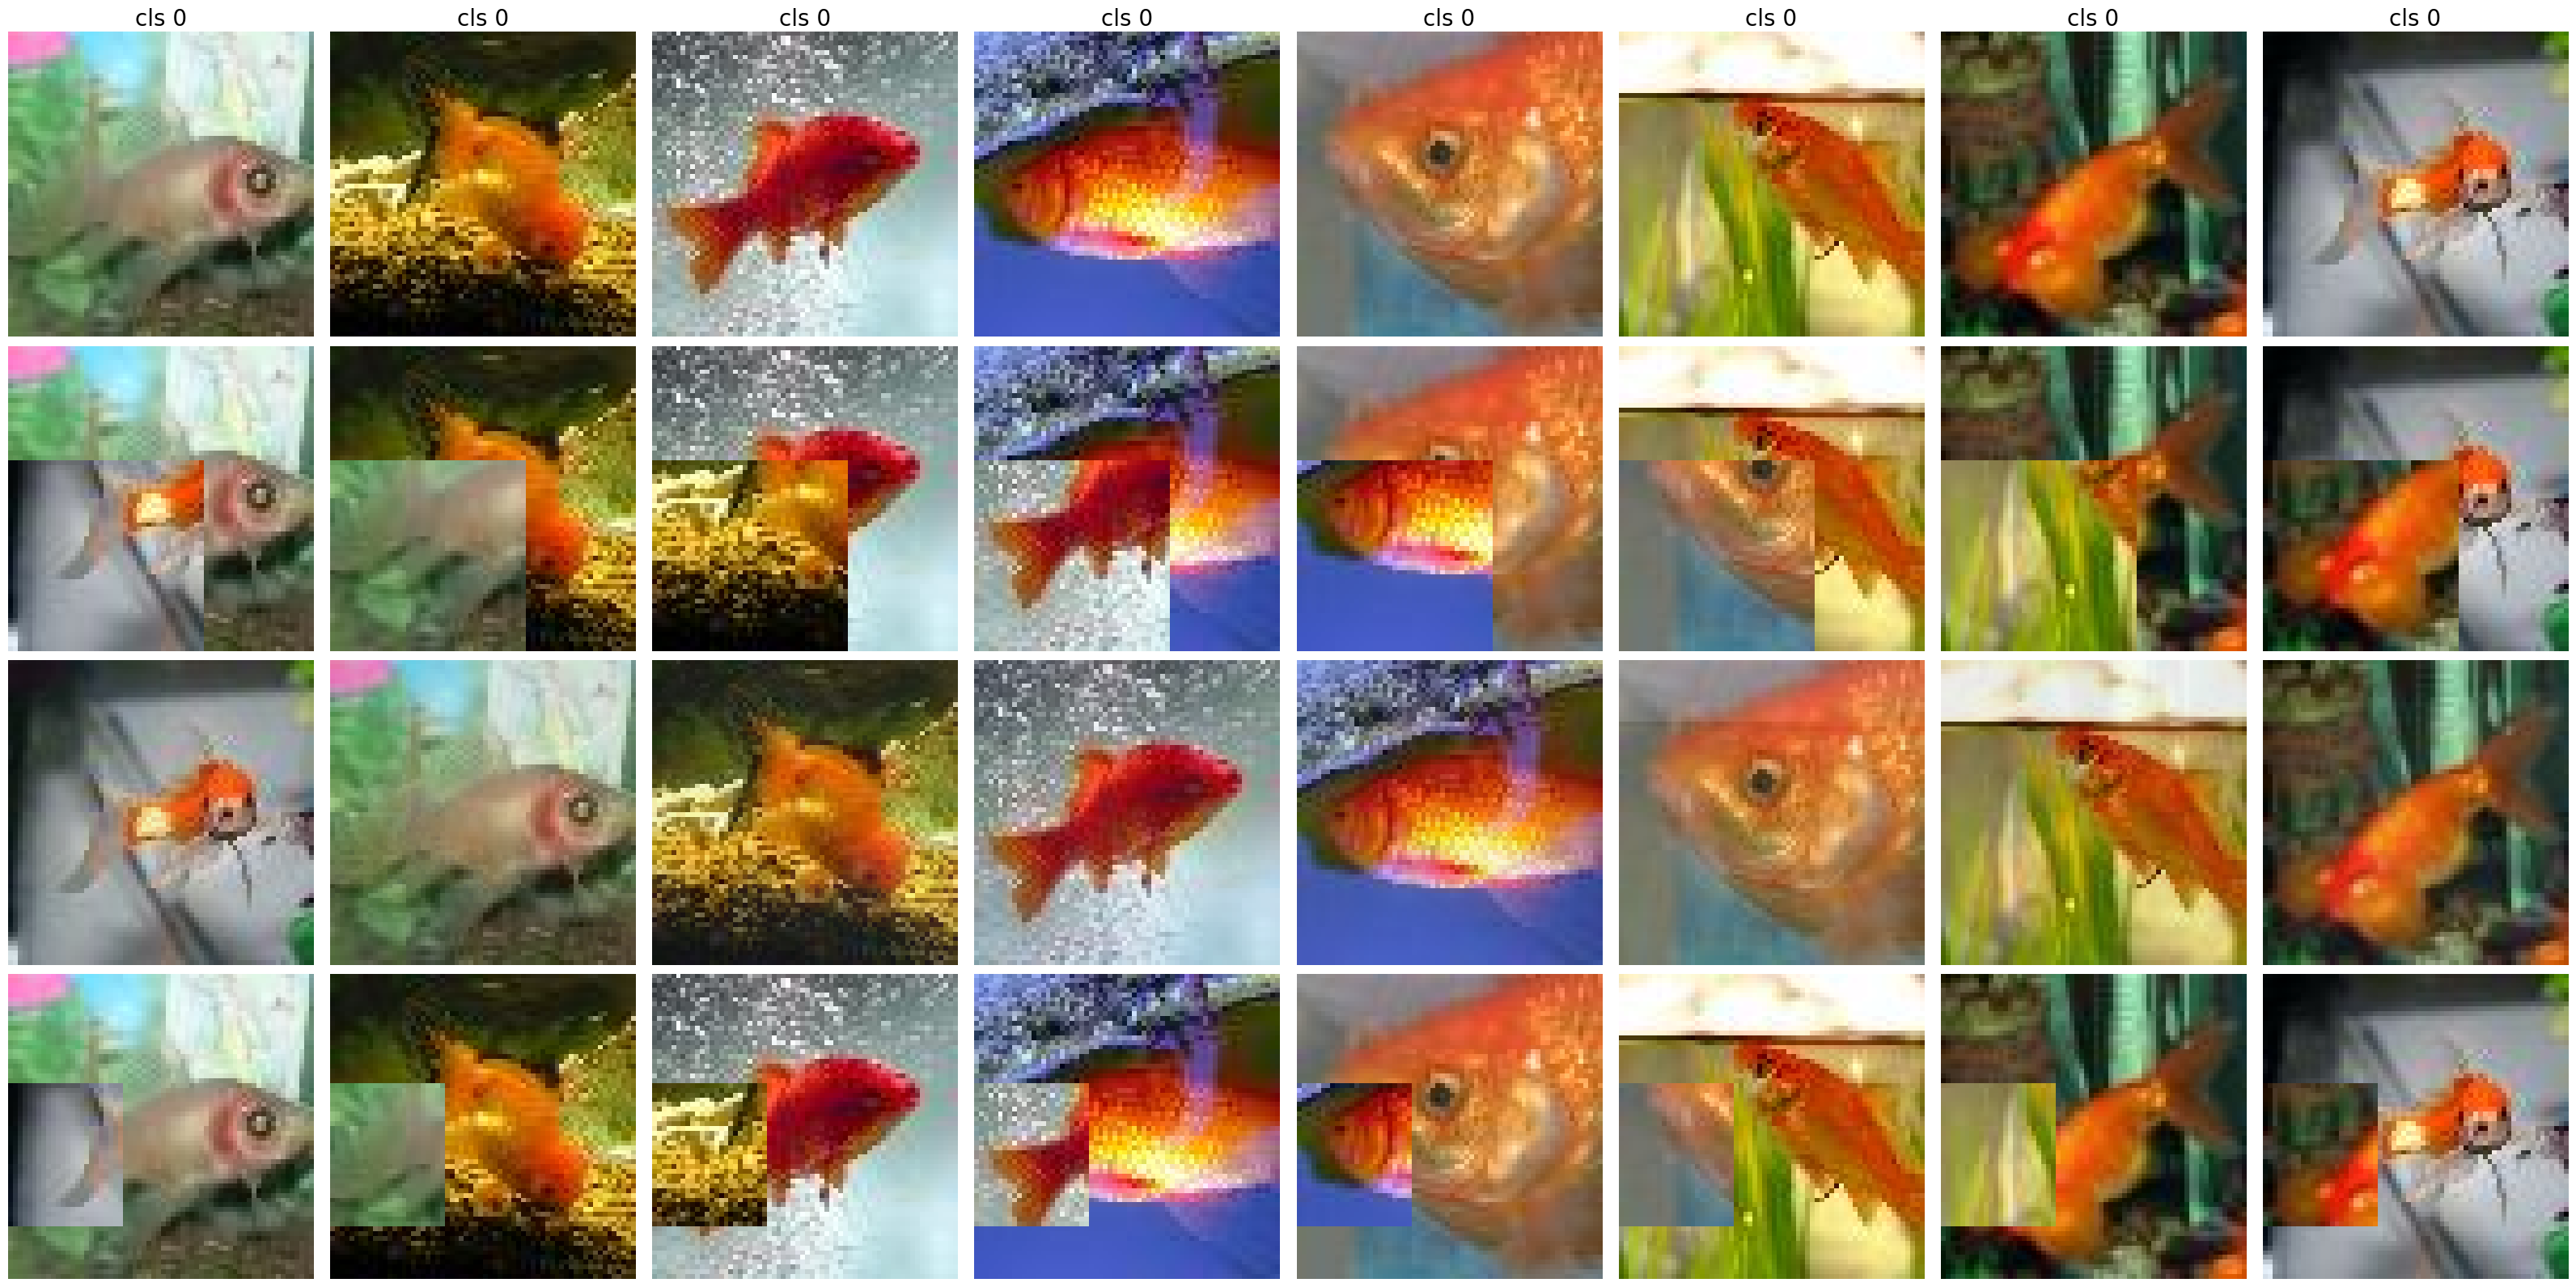

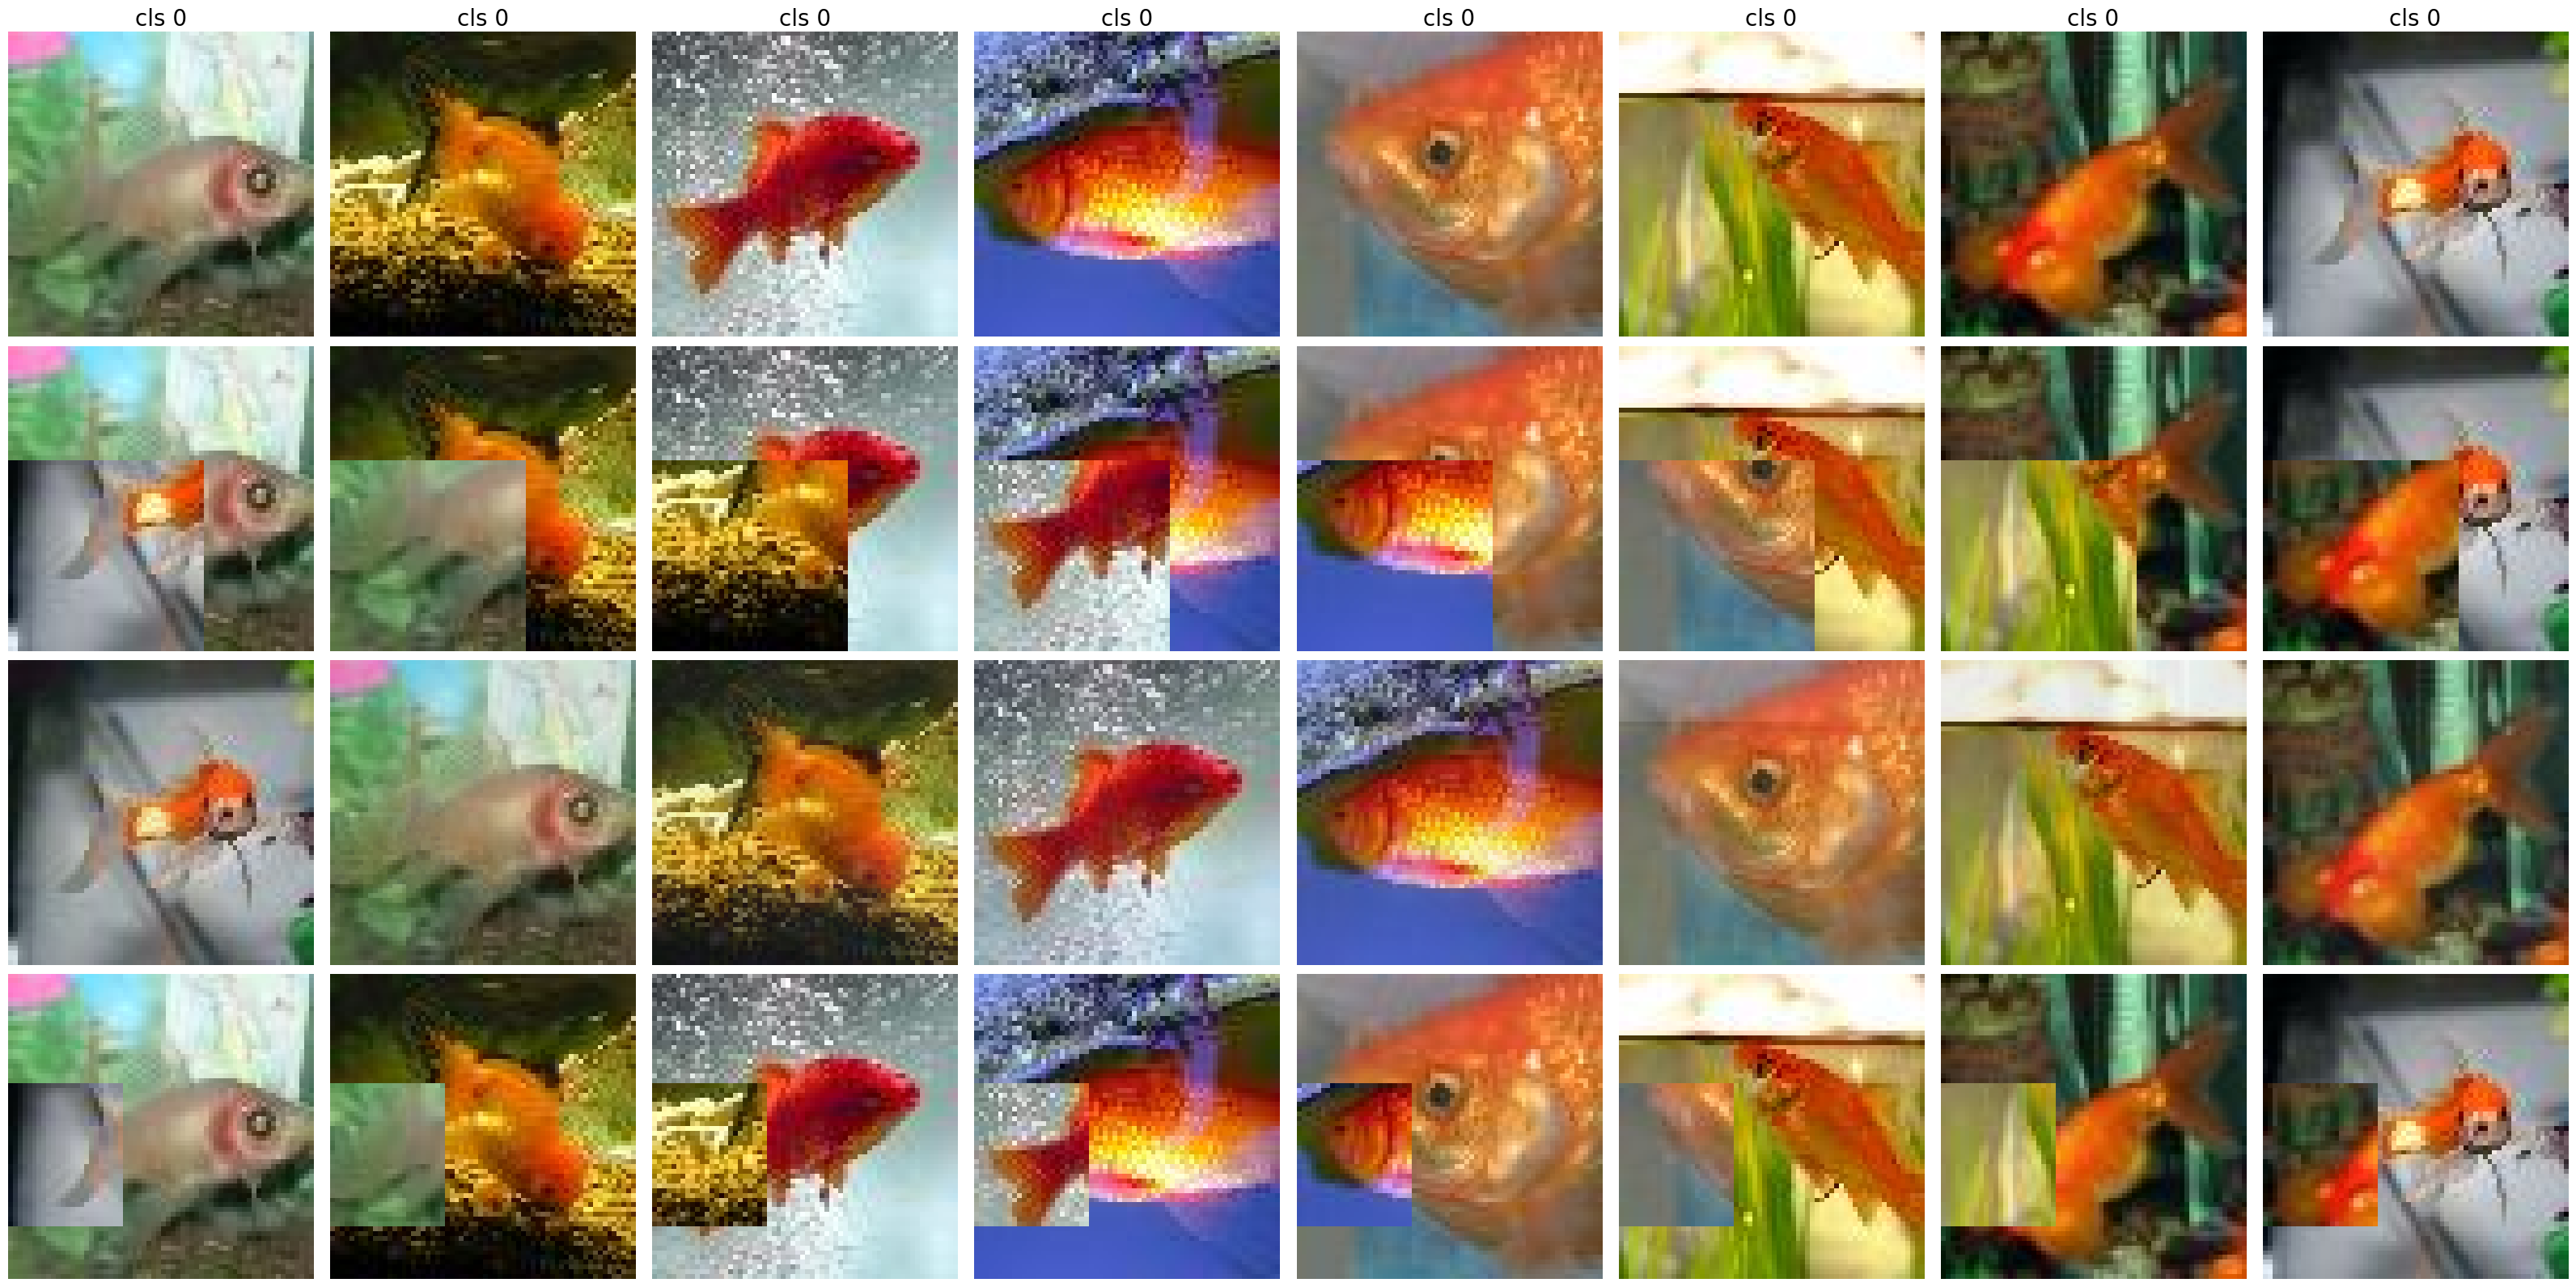

In [33]:
from mlxops_utils import denormalize
from mlxops_utils.plotting_utils import plot_hor

def to_hwc(images):
    imgs = denormalize(images.cpu(), IMAGENET_MEAN, IMAGENET_STD).clamp(0, 1)
    return [img.permute(1, 2, 0).numpy() for img in imgs]

def apply_aug(aug, x, y):
    result = aug(x.clone(), y.clone())
    return aug.get_x_y(result)

cutmix_aug   = CutMixUp(num_classes=NUM_CLASSES, config={"use_cutmix": True,  "use_mixup": False, "prob": 1.0})
mixup_aug    = CutMixUp(num_classes=NUM_CLASSES, config={"use_cutmix": False, "use_mixup": True,  "prob": 1.0})
cutmixup_aug = CutMixUp(num_classes=NUM_CLASSES, config={"use_cutmix": True,  "use_mixup": True,  "prob": 1.0})

x_cutmix,   _ = apply_aug(cutmix_aug,   x_batch, y_batch)
x_mixup,    _ = apply_aug(mixup_aug,    x_batch, y_batch)
x_cutmixup, _ = apply_aug(cutmixup_aug, x_batch, y_batch)

col_titles = [f"cls {y_batch[j].item()}" for j in range(N)]

plot_hor(
    [to_hwc(x_batch),
     to_hwc(x_cutmix),
     to_hwc(x_mixup),
     to_hwc(x_cutmixup)],
    rows=4, columns=N,
    subplot_titles=col_titles,
    idx=["Original", "CutMix", "MixUp", "CutMixUp"],
)

## PuzzleMix

PuzzleMix uses saliency maps (model gradients w.r.t. the input) to guide mixing —
salient regions from each image are preserved in the final blend.

> Requires `pip install "mlxops-aug[puzzlemix]"`

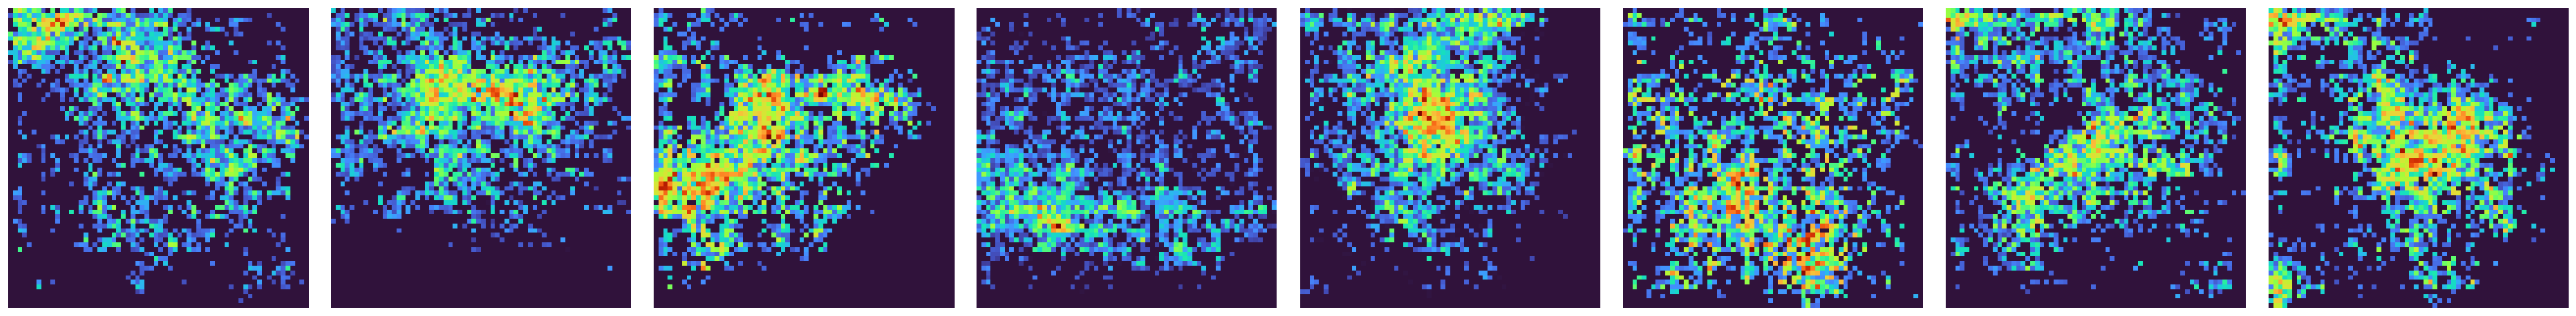

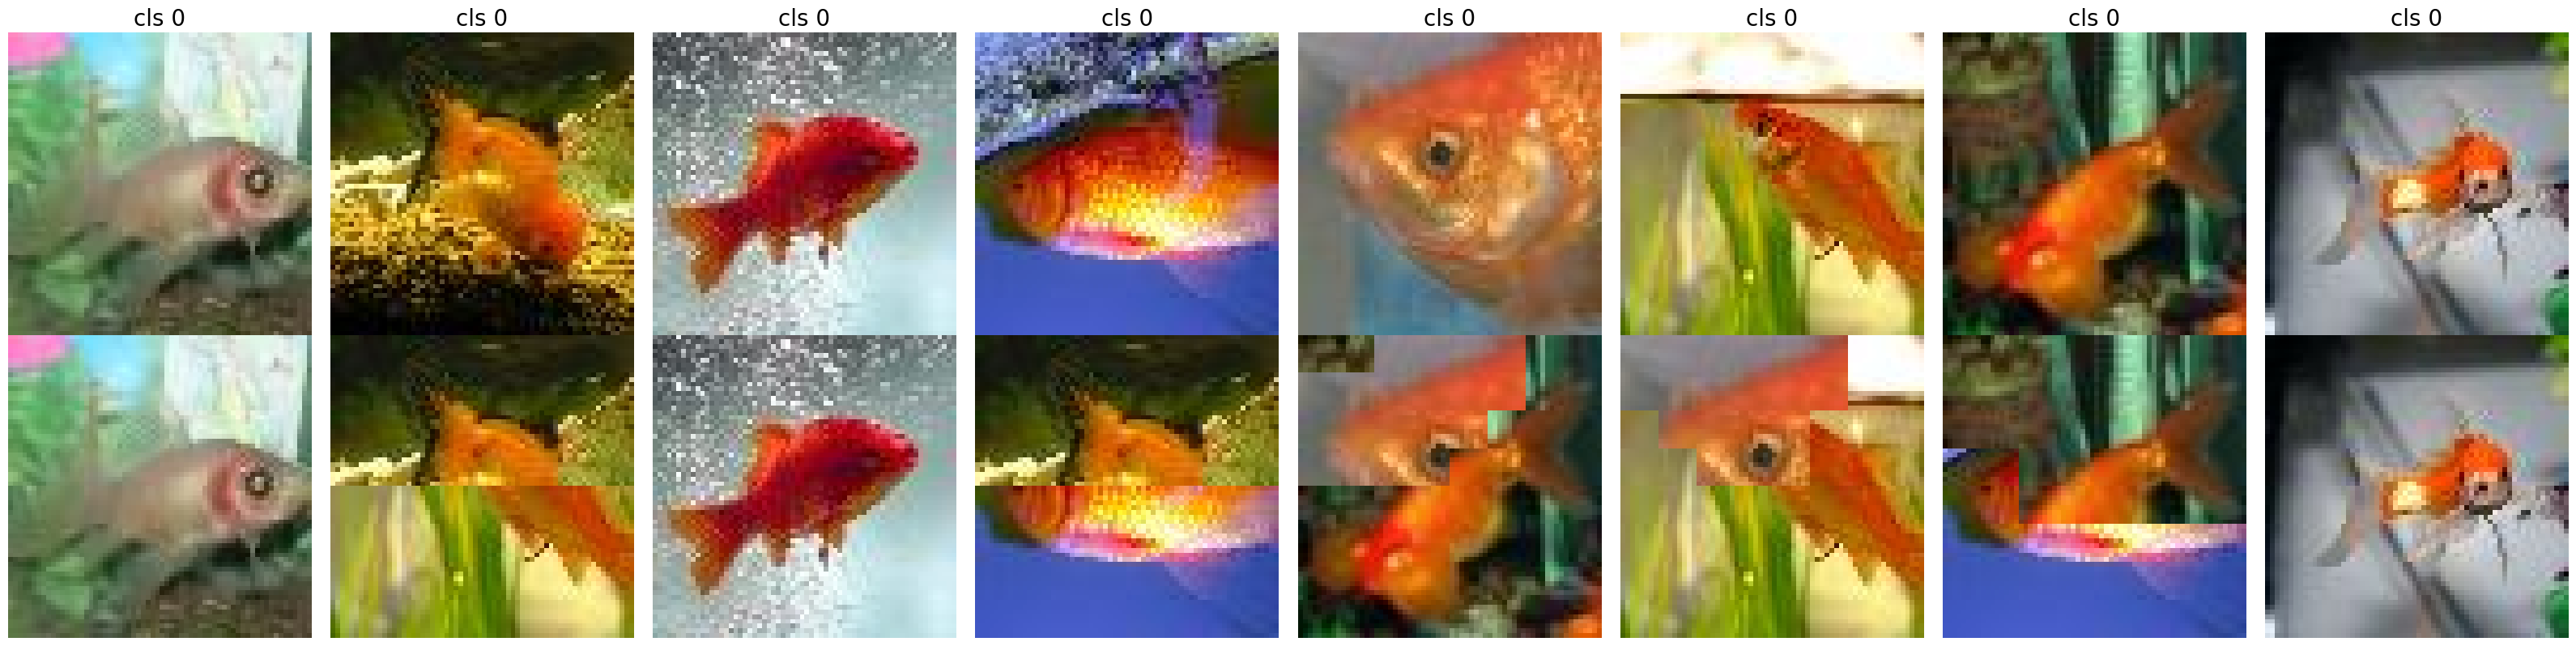

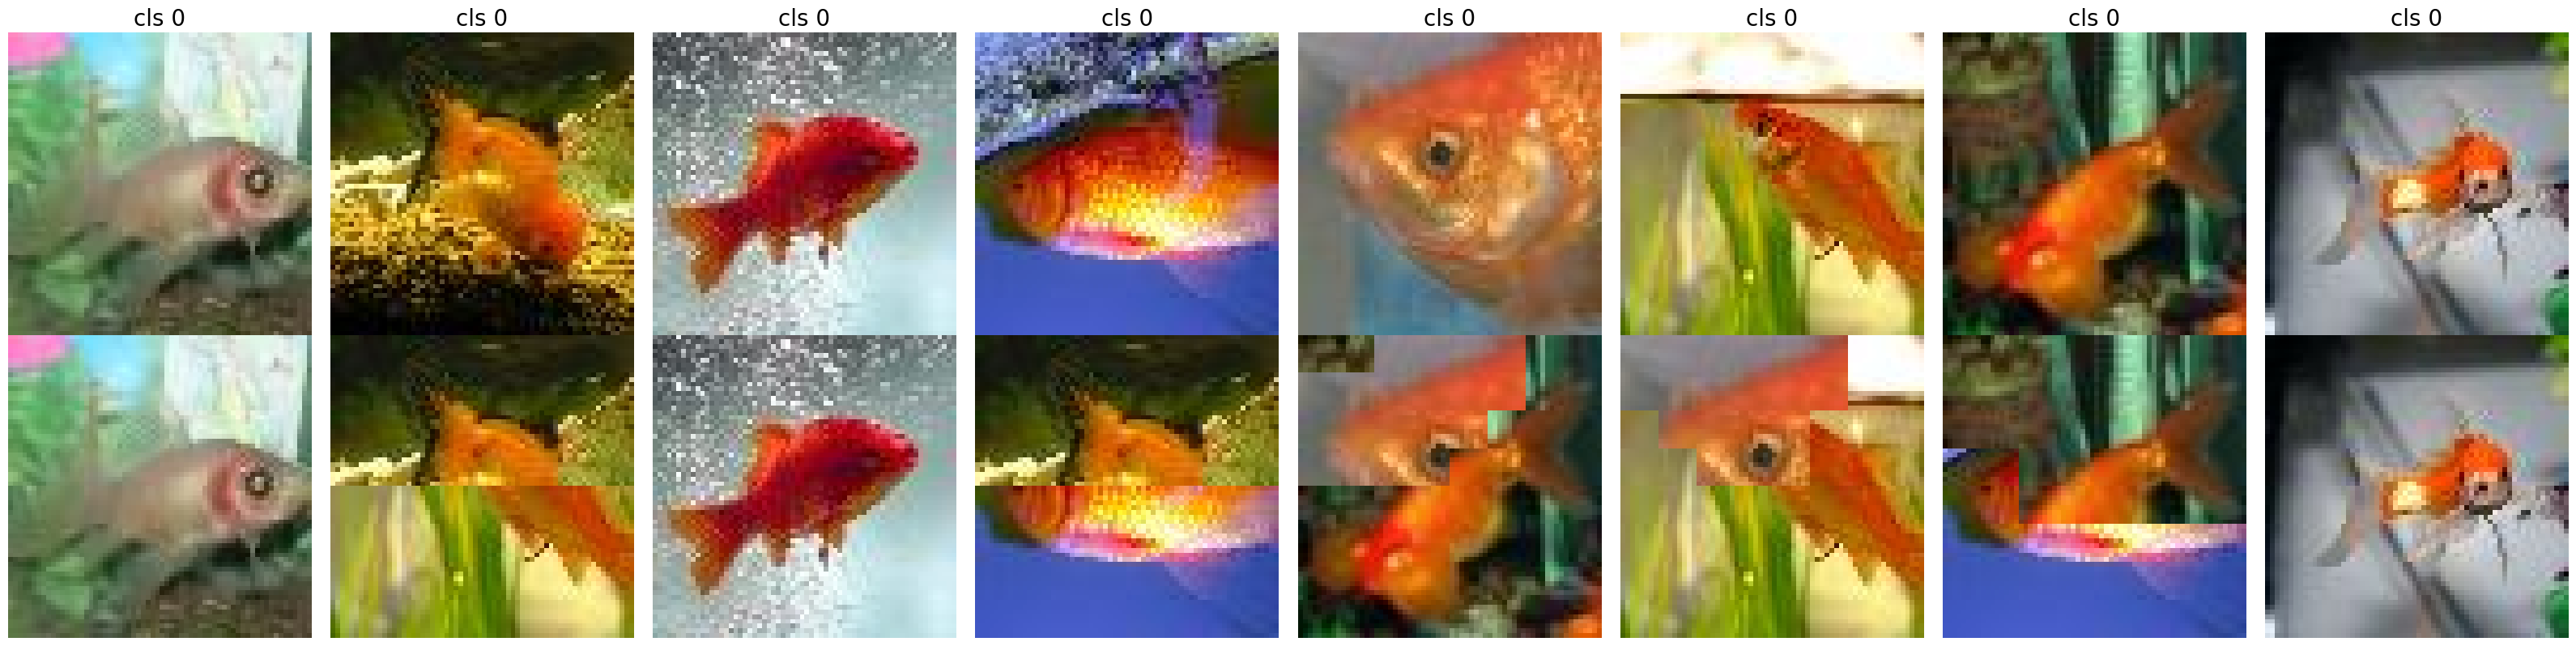

In [53]:
from mlxops_aug import PuzzleMix
from mlxops_xai import gradient
import torchvision.models as tv_models

backbone = tv_models.resnet50(weights=tv_models.ResNet50_Weights.DEFAULT)
backbone = backbone.to(DEVICE).eval()

puzzle_aug = PuzzleMix(
    num_classes=NUM_CLASSES,
    config={
        "block_num": 4,   # 4x4=16 patches, more visible puzzle effect
        "transport": True,
        "beta": 1.2,
        "gamma": 0.5,
        "eta": 0.2,
        "prob": 1.0,
        "debug": True,
        "saliency_conf": {
            "method": "guided_absolute_grad",
            "method_kwargs": {
                "th": 0.75
            }
        }
    },
)

x_puzzle, (ya, yb, lam) = puzzle_aug.aug(x_batch, y_batch, backbone)

plot_hor(
    [to_hwc(x_batch), to_hwc(x_puzzle)],
    rows=2, columns=N,
    subplot_titles=col_titles,
    idx=["Original", "Saliency", "PuzzleMix"],
)

### Verify PuzzleMix x–y correspondence

For each augmented image, show: **Image A | Image B (mixed in) | Result**, with the `lam` mixing ratio and label check.

✓ ya == y_batch
✓ lam in [0,1]: [1.   0.5  1.   0.5  0.3  0.7  0.56 1.  ]

Per-image breakdown:
  img[0]  ya=  0  yb=  0  lam=1.000  partner_in_batch=0  top2_soft=[1.0, 0.0]
  img[1]  ya=  0  yb=  0  lam=0.500  partner_in_batch=0  top2_soft=[1.0, 0.0]
  img[2]  ya=  0  yb=  0  lam=1.000  partner_in_batch=0  top2_soft=[1.0, 0.0]
  img[3]  ya=  0  yb=  0  lam=0.500  partner_in_batch=0  top2_soft=[1.0, 0.0]
  img[4]  ya=  0  yb=  0  lam=0.297  partner_in_batch=0  top2_soft=[1.0, 0.0]
  img[5]  ya=  0  yb=  0  lam=0.703  partner_in_batch=0  top2_soft=[1.0, 0.0]
  img[6]  ya=  0  yb=  0  lam=0.562  partner_in_batch=0  top2_soft=[1.0, 0.0]
  img[7]  ya=  0  yb=  0  lam=1.000  partner_in_batch=0  top2_soft=[1.0, 0.0]


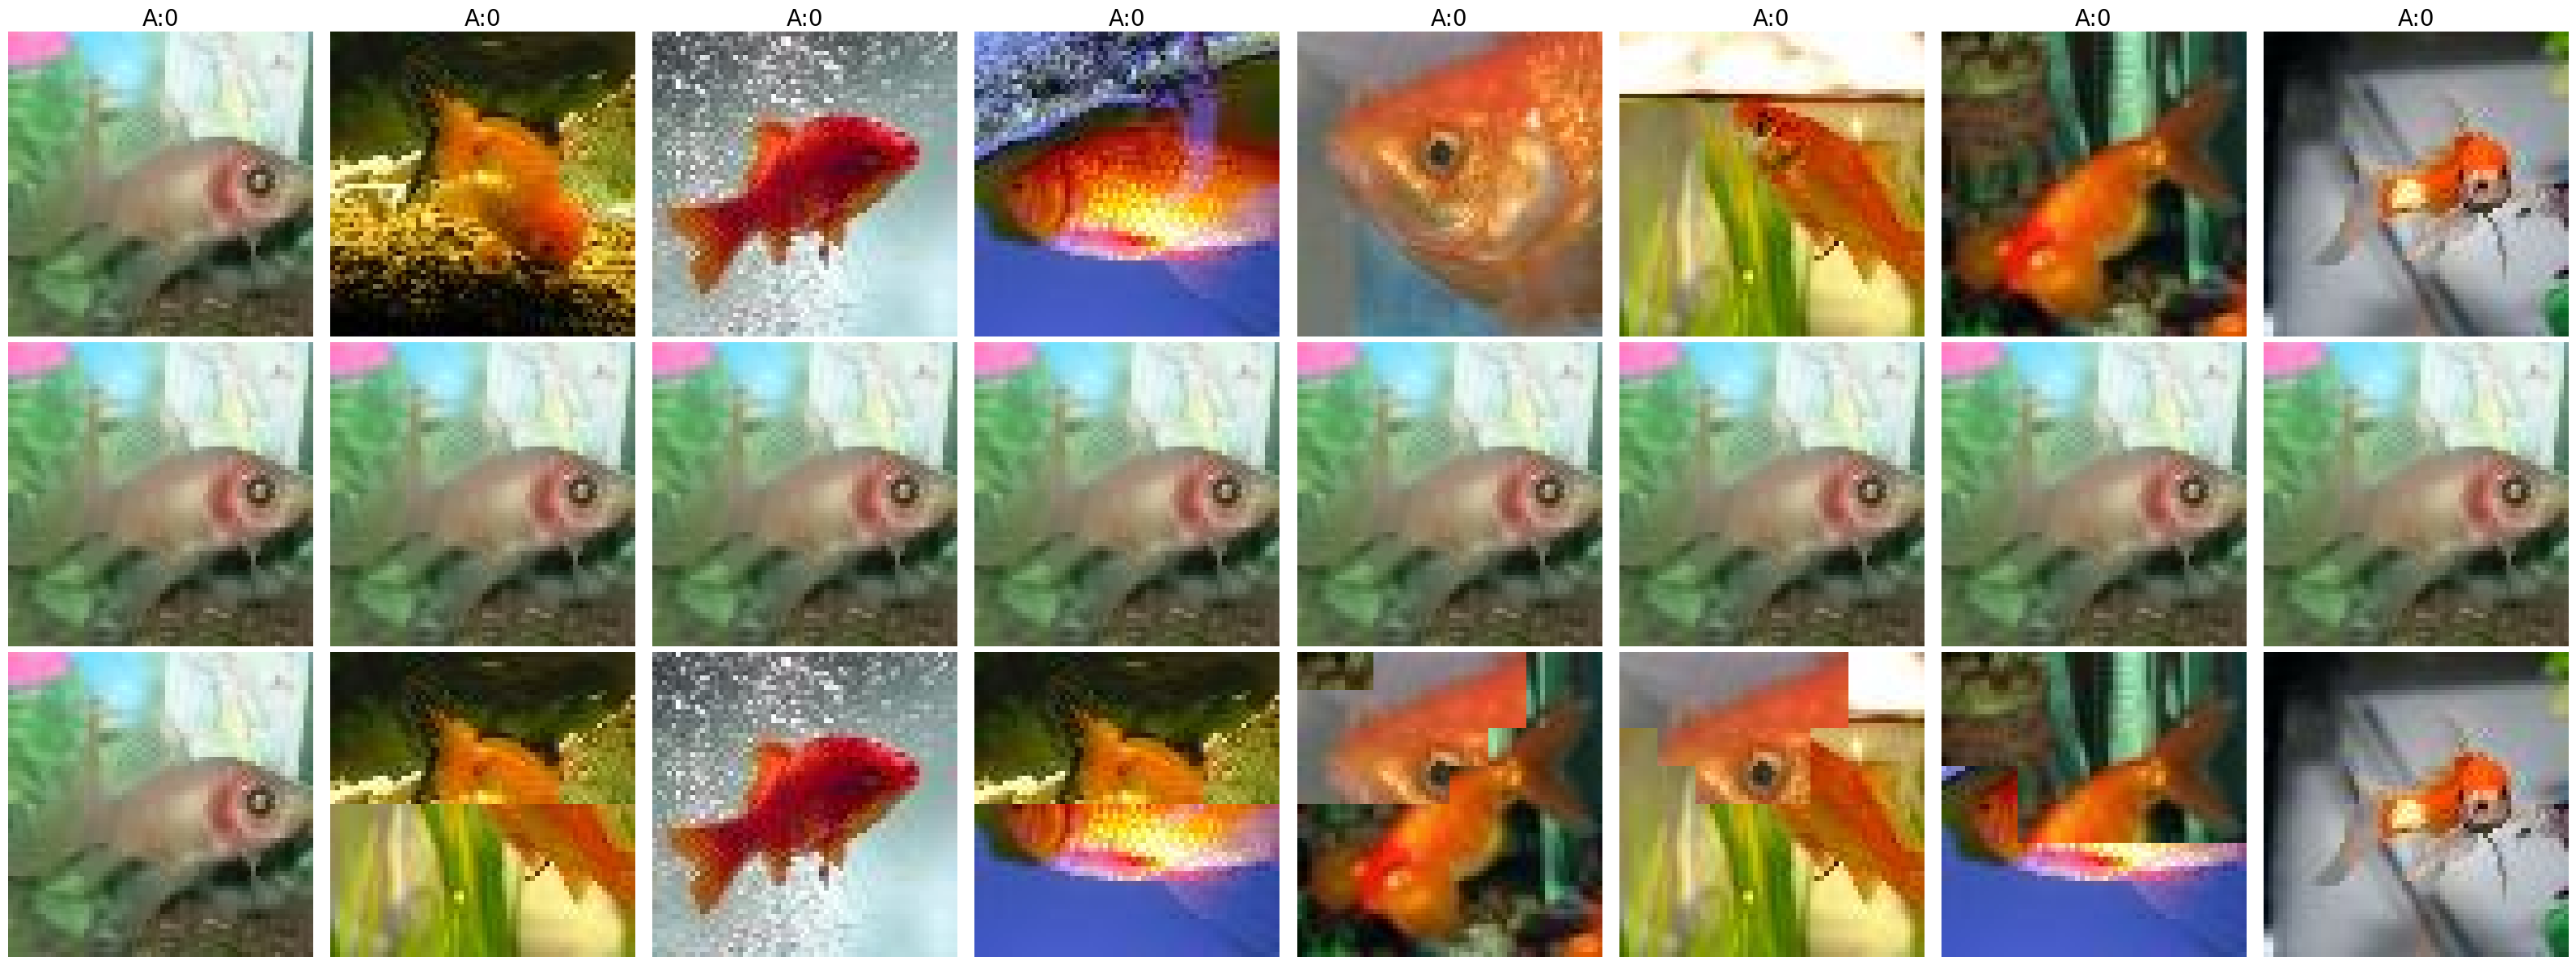

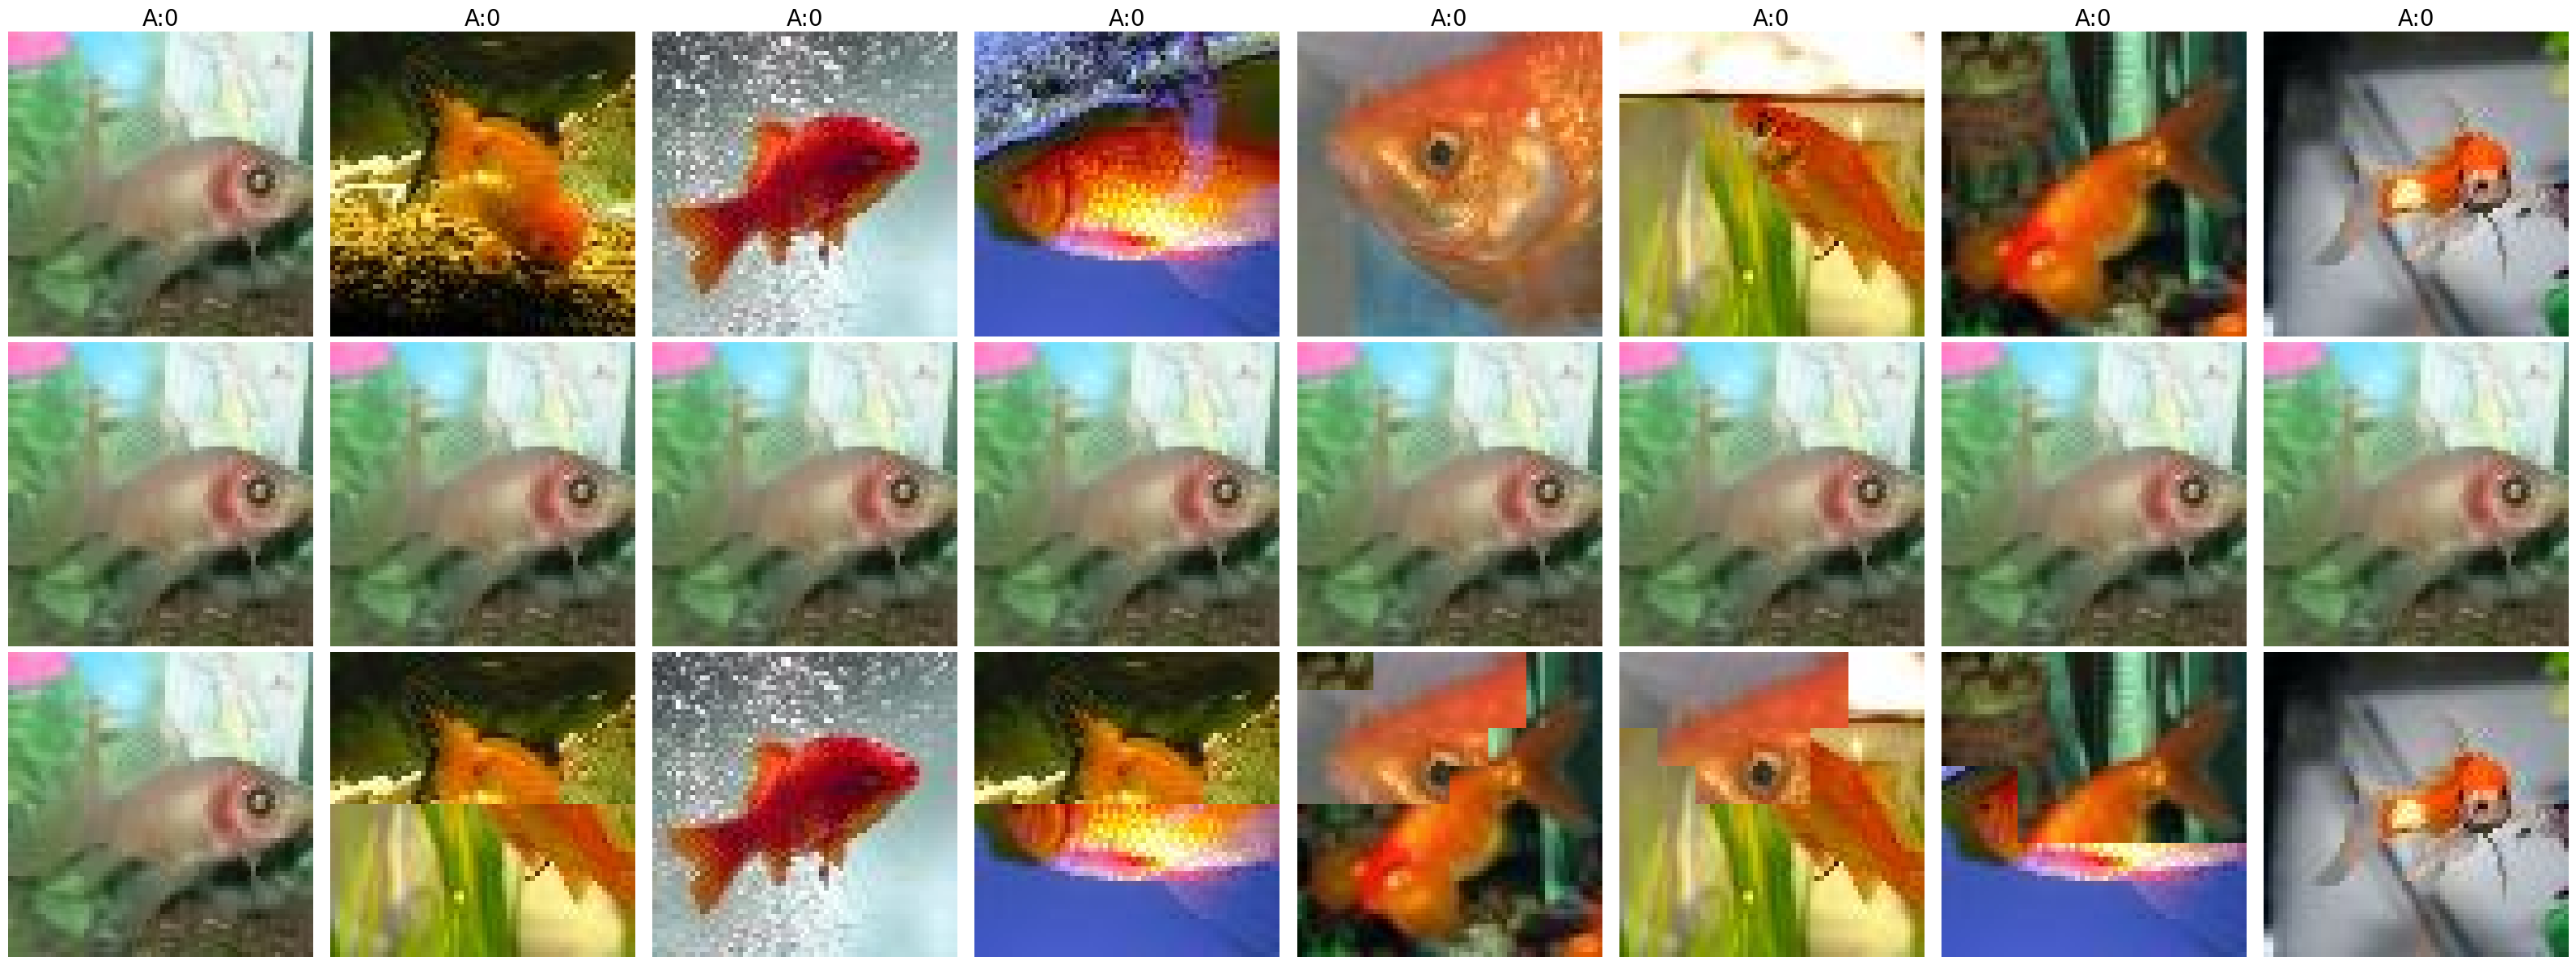

In [54]:
import torch.nn.functional as F

# ya should equal the original y_batch exactly
assert (ya == y_batch).all(), "ya does not match y_batch!"
print("✓ ya == y_batch")

# lam should be in [0, 1]
assert lam.min() >= 0 and lam.max() <= 1, f"lam out of range: {lam}"
print(f"✓ lam in [0,1]: {lam.cpu().numpy().round(2)}")

# Verify soft label = lam * one_hot(ya) + (1-lam) * one_hot(yb)
oh_a  = F.one_hot(ya,  NUM_CLASSES).float()
oh_b  = F.one_hot(yb,  NUM_CLASSES).float()
ll    = lam.reshape(-1, 1)
expected_y = oh_a * ll + oh_b * (1 - ll)

# Show per-image: Image A | Image B (partner) | PuzzleMix result | lam
print("\nPer-image breakdown:")
for i in range(N):
    # Find the partner in x_batch by matching yb[i]; pick first match
    partner_mask = (y_batch == yb[i])
    partner_idx  = partner_mask.nonzero(as_tuple=True)[0][0].item()
    print(
        f"  img[{i}]  ya={ya[i].item():3d}  yb={yb[i].item():3d}"
        f"  lam={lam[i].item():.3f}  partner_in_batch={partner_idx}"
        f"  top2_soft={expected_y[i].topk(2).values.tolist()}"
    )

# Visual: for each image, show [A, B(partner), result] as 3-row grid
row_a      = to_hwc(x_batch)
row_result = to_hwc(x_puzzle)

# Build partner row: x_batch[partner_idx] for each i
partners  = torch.stack([
    x_batch[(y_batch == yb[i]).nonzero(as_tuple=True)[0][0]] for i in range(N)
])
row_b = to_hwc(partners)

plot_hor(
    [row_a, row_b, row_result],
    rows=3, columns=N,
    subplot_titles=[f"A:{ya[j].item()}" for j in range(N)],
    idx=["Image A", "Image B (mixed in)", "PuzzleMix result"],
)